<a href="https://colab.research.google.com/github/nishalahmedpk/graphrag-timeseries/blob/main/mimic_iv_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q google-cloud-bigquery pandas pyarrow

In [3]:
from google.colab import auth
auth.authenticate_user()
print("Authenticated")

Authenticated


In [4]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "methodical-mark-493108-d4"

client = bigquery.Client(project=PROJECT_ID)

def run_query(sql: str) -> pd.DataFrame:
    """Run a SQL query on BigQuery and return a pandas DataFrame."""
    job = client.query(sql)
    return job.to_dataframe()

In [5]:
df_test = run_query("""
SELECT *
FROM `physionet-data.mimiciv_3_1_hosp.patients`
LIMIT 10;
""")
df_test

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10078138,F,18,2110,2017 - 2019,NaT
1,10180372,M,18,2110,2008 - 2010,NaT
2,10686175,M,18,2110,2011 - 2013,NaT
3,10851602,F,18,2110,2014 - 2016,NaT
4,10902424,F,18,2110,2017 - 2019,NaT
5,11092326,M,18,2110,2008 - 2010,NaT
6,11289691,F,18,2110,2017 - 2019,NaT
7,11595073,M,18,2110,2011 - 2013,NaT
8,11739764,F,18,2110,2017 - 2019,NaT
9,11776346,F,18,2110,2008 - 2010,NaT


In [5]:
def summarize_df(df: pd.DataFrame, name: str = "table"):
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print("\nmissing (top 10):")
    print(df.isna().sum().sort_values(ascending=False).head(10))
    print("\ndtypes:")
    print(df.dtypes)

In [6]:
def get_core_stay_context(stay_id: int) -> pd.DataFrame:
    sql = f"""
    SELECT
      i.stay_id,
      i.subject_id,
      i.hadm_id,
      i.first_careunit,
      i.last_careunit,
      i.intime,
      i.outtime,
      p.gender,
      p.anchor_age,
      p.anchor_year_group,
      a.admission_type,
      a.insurance,
      a.language,
      a.marital_status,
      a.race
    FROM `physionet-data.mimiciv_3_1_icu.icustays` AS i
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` AS p
      ON i.subject_id = p.subject_id
    JOIN `physionet-data.mimiciv_3_1_hosp.admissions` AS a
      ON i.hadm_id = a.hadm_id
    WHERE i.stay_id = {stay_id}
    """
    df = run_query(sql)
    return df

In [7]:
# Get one random stay_id to play with
one_stay = run_query("""
SELECT stay_id
FROM `physionet-data.mimiciv_3_1_icu.icustays`
ORDER BY RAND()
LIMIT 1;
""")
stay_id = int(one_stay["stay_id"].iloc[0])
stay_id

33401329

In [8]:
core = get_core_stay_context(stay_id)
summarize_df(core, "core_stay_context")
core


=== core_stay_context ===
shape: (1, 15)
columns: ['stay_id', 'subject_id', 'hadm_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'gender', 'anchor_age', 'anchor_year_group', 'admission_type', 'insurance', 'language', 'marital_status', 'race']

missing (top 10):
stay_id              0
subject_id           0
hadm_id              0
first_careunit       0
last_careunit        0
intime               0
outtime              0
gender               0
anchor_age           0
anchor_year_group    0
dtype: int64

dtypes:
stay_id                       Int64
subject_id                    Int64
hadm_id                       Int64
first_careunit               object
last_careunit                object
intime               datetime64[us]
outtime              datetime64[us]
gender                       object
anchor_age                    Int64
anchor_year_group            object
admission_type               object
insurance                    object
language                     object
mar

,stay_id,subject_id,hadm_id,first_careunit,last_careunit,intime,outtime,gender,anchor_age,anchor_year_group,admission_type,insurance,language,marital_status,race
0,33401329,19660133,28534495,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2125-07-16 01:18:23,2125-07-16 21:24:00,M,33,2008 - 2010,EW EMER.,Private,English,MARRIED,WHITE


In [9]:
def get_stay_labs(stay_id: int, hours: int = 24) -> pd.DataFrame:
    sql = f"""
    WITH stay AS (
      SELECT stay_id, subject_id, hadm_id, intime
      FROM `physionet-data.mimiciv_3_1_icu.icustays`
      WHERE stay_id = {stay_id}
    )
    SELECT
      l.subject_id,
      l.hadm_id,
      l.itemid,
      l.charttime,
      l.valuenum,
      l.valueuom
    FROM `physionet-data.mimiciv_3_1_hosp.labevents` AS l
    JOIN stay AS s
      ON l.hadm_id = s.hadm_id
    WHERE l.charttime BETWEEN s.intime
          AND DATETIME_ADD(s.intime, INTERVAL {hours} HOUR)
      AND l.valuenum IS NOT NULL
    ORDER BY l.charttime
    """
    df = run_query(sql)
    return df

In [10]:
labs_24h = get_stay_labs(stay_id, hours=24)
summarize_df(labs_24h, "labs_24h")
labs_24h.head()


=== labs_24h ===
shape: (53, 6)
columns: ['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum', 'valueuom']

missing (top 10):
subject_id    0
hadm_id       0
itemid        0
charttime     0
valuenum      0
valueuom      0
dtype: int64

dtypes:
subject_id             Int64
hadm_id                Int64
itemid                 Int64
charttime     datetime64[us]
valuenum             float64
valueuom              object
dtype: object


,subject_id,hadm_id,itemid,charttime,valuenum,valueuom
0,19660133,28534495,50893,2125-07-16 08:34:00,7.3,mg/dL
1,19660133,28534495,50983,2125-07-16 08:34:00,133.0,mEq/L
2,19660133,28534495,51249,2125-07-16 08:34:00,33.9,%
3,19660133,28534495,51265,2125-07-16 08:34:00,126.0,K/uL
4,19660133,28534495,51250,2125-07-16 08:34:00,80.0,fL


In [11]:
def get_stay_vitals(stay_id: int, hours: int = 24) -> pd.DataFrame:
    sql = f"""
    WITH stay AS (
      SELECT stay_id, intime
      FROM `physionet-data.mimiciv_3_1_icu.icustays`
      WHERE stay_id = {stay_id}
    )
    SELECT
      c.stay_id,
      c.itemid,
      c.charttime,
      c.valuenum,
      c.valueuom
    FROM `physionet-data.mimiciv_3_1_icu.chartevents` AS c
    JOIN stay AS s
      ON c.stay_id = s.stay_id
    WHERE c.charttime BETWEEN s.intime
          AND DATETIME_ADD(s.intime, INTERVAL {hours} HOUR)
      AND c.valuenum IS NOT NULL
    ORDER BY c.charttime
    """
    df = run_query(sql)
    return df

In [12]:
vitals_24h = get_stay_vitals(stay_id, hours=24)
summarize_df(vitals_24h, "vitals_24h")
vitals_24h.head()


=== vitals_24h ===
shape: (291, 5)
columns: ['stay_id', 'itemid', 'charttime', 'valuenum', 'valueuom']

missing (top 10):
valueuom     129
stay_id        0
itemid         0
charttime      0
valuenum       0
dtype: int64

dtypes:
stay_id               Int64
itemid                Int64
charttime    datetime64[us]
valuenum            float64
valueuom             object
dtype: object


,stay_id,itemid,charttime,valuenum,valueuom
0,33401329,220045,2125-07-16 03:14:00,94.0,bpm
1,33401329,220180,2125-07-16 03:14:00,98.0,mmHg
2,33401329,220181,2125-07-16 03:14:00,114.0,mmHg
3,33401329,220179,2125-07-16 03:14:00,174.0,mmHg
4,33401329,220210,2125-07-16 03:14:00,18.0,insp/min


In [13]:
def get_admission_diagnoses(hadm_id: int) -> pd.DataFrame:
    sql = f"""
    SELECT d.*
    FROM `physionet-data.mimiciv_3_1_hosp.diagnoses_icd` AS d
    WHERE d.hadm_id = {hadm_id}
    """
    return run_query(sql)

In [14]:
hadm_id = int(core["hadm_id"].iloc[0])
diagnoses = get_admission_diagnoses(hadm_id)
summarize_df(diagnoses, "diagnoses")
diagnoses.head()


=== diagnoses ===
shape: (22, 5)
columns: ['subject_id', 'hadm_id', 'seq_num', 'icd_code', 'icd_version']

missing (top 10):
subject_id     0
hadm_id        0
seq_num        0
icd_code       0
icd_version    0
dtype: int64

dtypes:
subject_id      Int64
hadm_id         Int64
seq_num         Int64
icd_code       object
icd_version     Int64
dtype: object


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,19660133,28534495,1,34839,9
1,19660133,28534495,2,5849,9
2,19660133,28534495,3,28319,9
3,19660133,28534495,4,40391,9
4,19660133,28534495,5,5855,9


In [15]:
def get_stay_bundle(stay_id: int, hours: int = 24):
    core = get_core_stay_context(stay_id)
    if core.empty:
        raise ValueError(f"stay_id {stay_id} not found")

    hadm_id = int(core["hadm_id"].iloc[0])

    labs = get_stay_labs(stay_id, hours=hours)
    vitals = get_stay_vitals(stay_id, hours=hours)
    diagnoses = get_admission_diagnoses(hadm_id)

    print(f"=== ICU stay {stay_id} (hadm_id={hadm_id}) ===")
    summarize_df(core, "core")
    summarize_df(labs, "labs")
    summarize_df(vitals, "vitals")
    summarize_df(diagnoses, "diagnoses")

    return {
        "core": core,
        "labs": labs,
        "vitals": vitals,
        "diagnoses": diagnoses,
    }

In [16]:
bundle = get_stay_bundle(stay_id, hours=24)
bundle["core"]

=== ICU stay 33401329 (hadm_id=28534495) ===

=== core ===
shape: (1, 15)
columns: ['stay_id', 'subject_id', 'hadm_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'gender', 'anchor_age', 'anchor_year_group', 'admission_type', 'insurance', 'language', 'marital_status', 'race']

missing (top 10):
stay_id              0
subject_id           0
hadm_id              0
first_careunit       0
last_careunit        0
intime               0
outtime              0
gender               0
anchor_age           0
anchor_year_group    0
dtype: int64

dtypes:
stay_id                       Int64
subject_id                    Int64
hadm_id                       Int64
first_careunit               object
last_careunit                object
intime               datetime64[us]
outtime              datetime64[us]
gender                       object
anchor_age                    Int64
anchor_year_group            object
admission_type               object
insurance                    object
languag

,stay_id,subject_id,hadm_id,first_careunit,last_careunit,intime,outtime,gender,anchor_age,anchor_year_group,admission_type,insurance,language,marital_status,race
0,33401329,19660133,28534495,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2125-07-16 01:18:23,2125-07-16 21:24:00,M,33,2008 - 2010,EW EMER.,Private,English,MARRIED,WHITE


In [22]:
def get_cohort_demographics(limit=10):
    sql = f"""
    SELECT
        i.stay_id, i.hadm_id,
        p.gender, p.anchor_age,
        a.admission_type, a.insurance, a.race, a.hospital_expire_flag
    FROM `physionet-data.mimiciv_3_1_icu.icustays` AS i
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` AS p ON i.subject_id = p.subject_id
    JOIN `physionet-data.mimiciv_3_1_hosp.admissions` AS a ON i.hadm_id = a.hadm_id
    LIMIT {limit}
    """
    return run_query(sql)

cohort_df = get_cohort_demographics(1000)

In [23]:
def get_pivoted_vitals(limit_stays=500):
    # Mapping common itemids to human names
    vitals_map = {
        220045: 'heart_rate',
        220210: 'resp_rate',
        220277: 'spo2',
        220179: 'sbp',
        223762: 'temp'
    }

    sql = f"""
    SELECT stay_id, itemid, valuenum
    FROM `physionet-data.mimiciv_3_1_icu.chartevents`
    WHERE itemid IN ({','.join(map(str, vitals_map.keys()))})
    AND stay_id IN (SELECT stay_id FROM `physionet-data.mimiciv_3_1_icu.icustays` LIMIT {limit_stays})
    """
    raw_vitals = run_query(sql)

    # Pivot Long to Wide
    pivoted = raw_vitals.pivot_table(index='stay_id', columns='itemid', values='valuenum')
    pivoted.rename(columns=vitals_map, inplace=True)
    return pivoted

vitals_wide = get_pivoted_vitals()

<Figure size 1200x600 with 0 Axes>

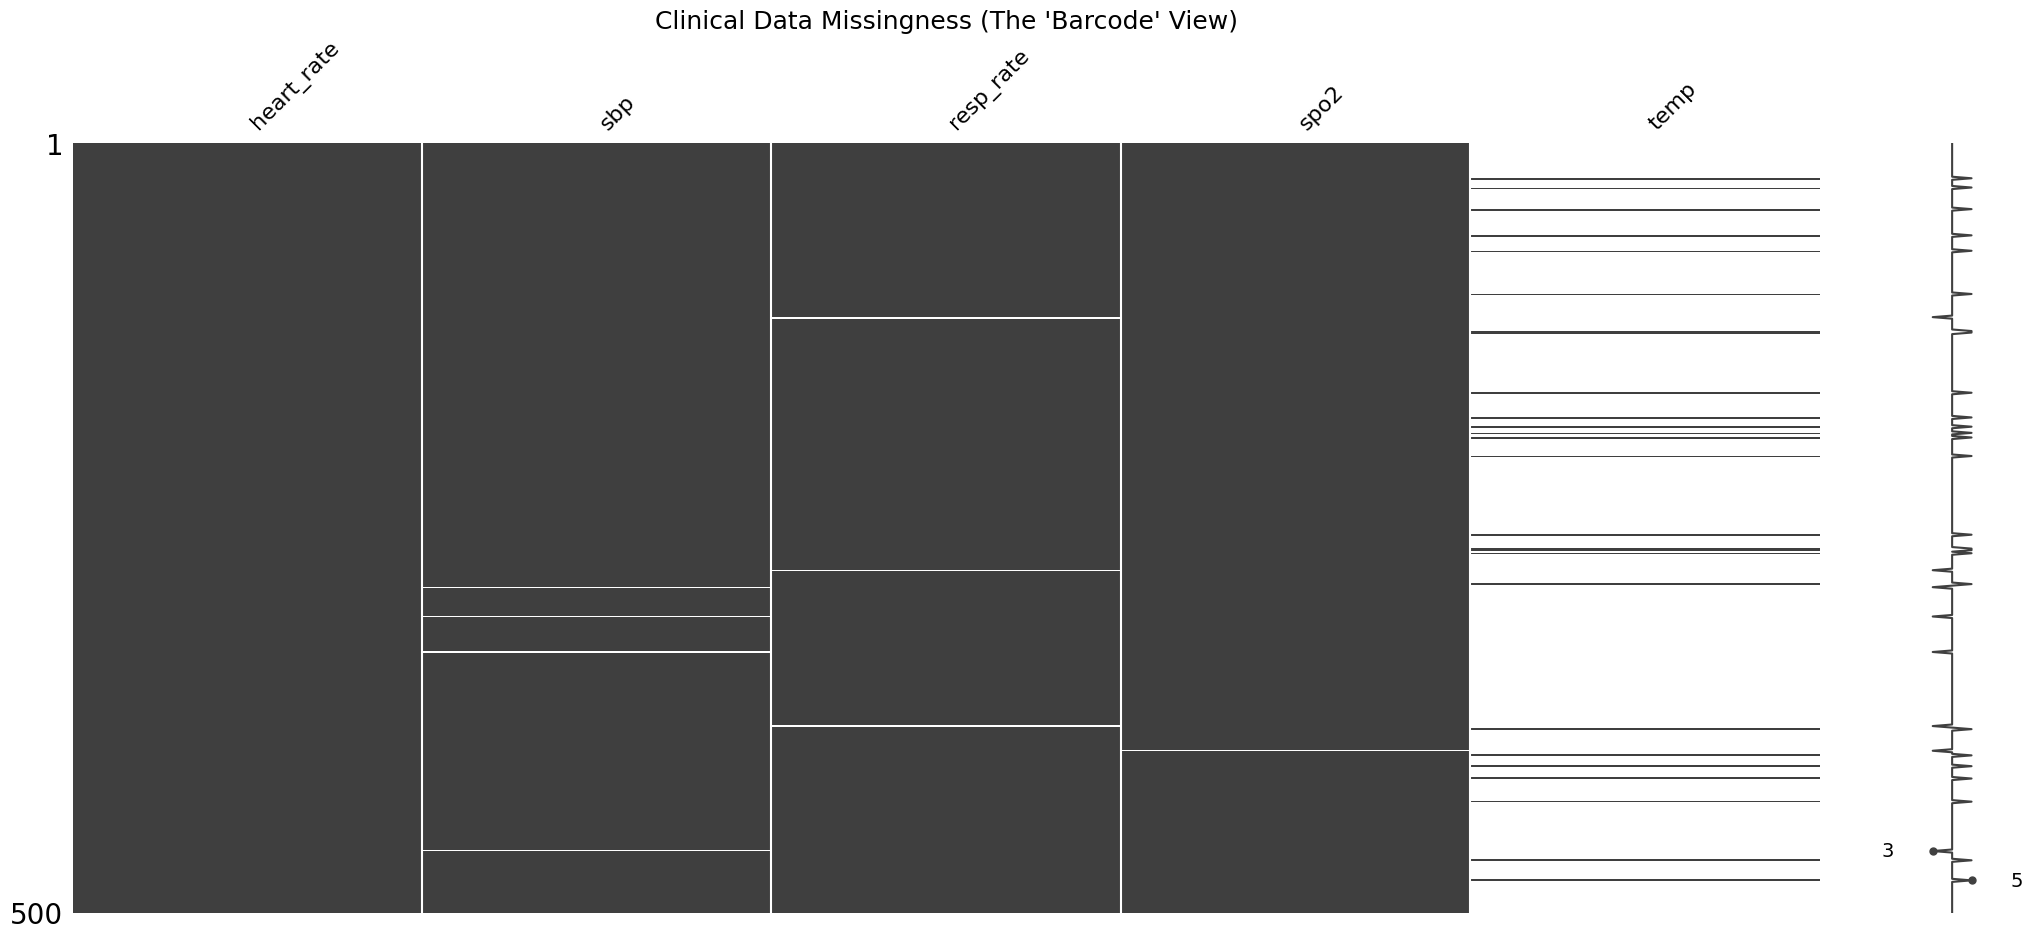

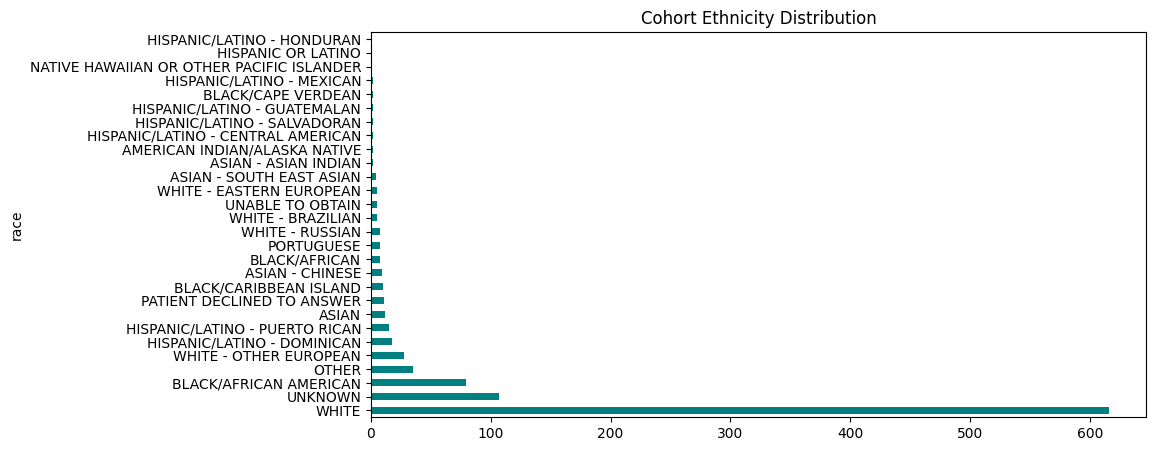

In [24]:
import missingno as msno
import matplotlib.pyplot as plt

# 1. Missingness Matrix
plt.figure(figsize=(12, 6))
msno.matrix(vitals_wide)
plt.title("Clinical Data Missingness (The 'Barcode' View)", fontsize=18)
plt.show()

# 2. Demographic Breakdown (matching your spreadsheet image)
plt.figure(figsize=(10, 5))
cohort_df['race'].value_counts().plot(kind='barh', color='teal')
plt.title("Cohort Ethnicity Distribution")
plt.show()

In [5]:
# To see what 220045 represents
run_query("""
SELECT itemid, label, abbreviation
FROM `physionet-data.mimiciv_3_1_icu.d_items`
WHERE itemid = 220045
""")

,itemid,label,abbreviation
0,220045,Heart Rate,HR


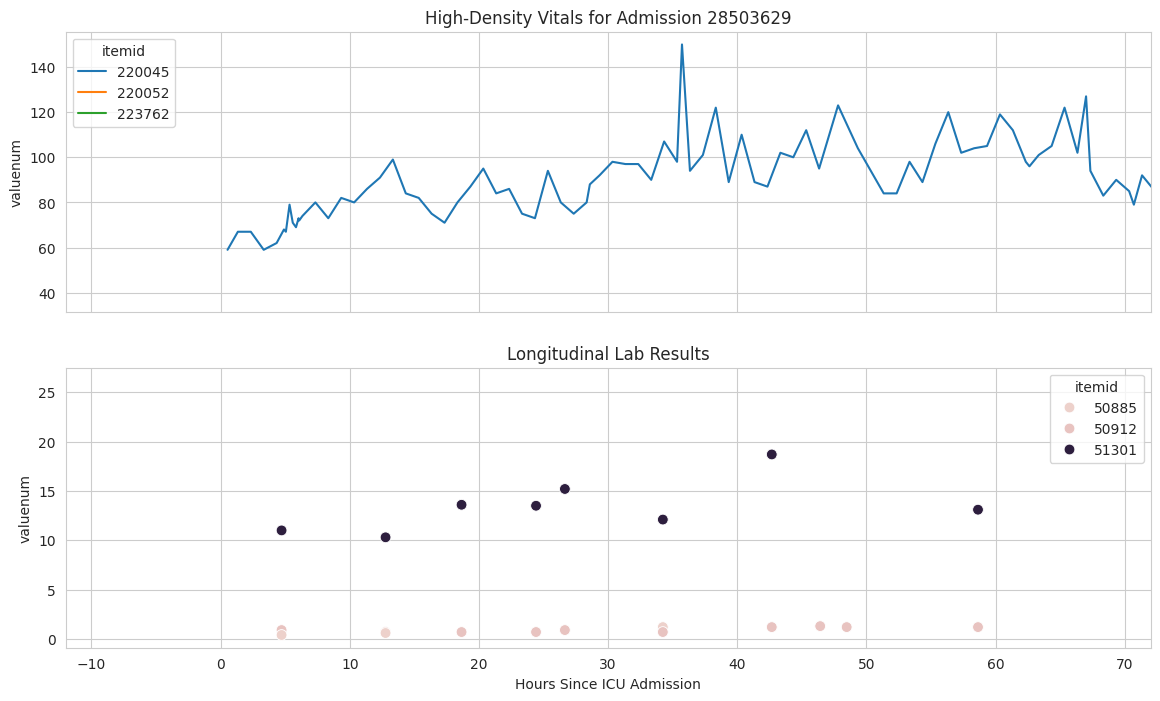

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_mimic_figure_1_fixed(hadm_id=28503629):
    # 1. Get the EARLIEST ICU intime for this admission as the 0-hour mark
    info = run_query(f"""
        SELECT subject_id, MIN(intime) as icu_anchor
        FROM `physionet-data.mimiciv_3_1_icu.icustays`
        WHERE hadm_id = {hadm_id}
        GROUP BY subject_id
    """)
    if info.empty: return print("Admission ID not found.")

    subj_id = info.iloc[0]['subject_id']
    icu_anchor = info.iloc[0]['icu_anchor']

    # 2. Vitals (Locked to hadm_id)
    v_sql = f"""
        SELECT (DATETIME_DIFF(charttime, '{icu_anchor}', MINUTE)/60.0) as hrs, valuenum, itemid
        FROM `physionet-data.mimiciv_3_1_icu.chartevents`
        WHERE hadm_id = {hadm_id} AND itemid IN (220045, 220052, 223762)
    """
    vitals = run_query(v_sql)

    # 3. Labs (CRITICAL: Added hadm_id filter to avoid pulling year-old data)
    l_sql = f"""
        SELECT (DATETIME_DIFF(charttime, '{icu_anchor}', MINUTE)/60.0) as hrs, valuenum, itemid
        FROM `physionet-data.mimiciv_3_1_hosp.labevents`
        WHERE hadm_id = {hadm_id} AND itemid IN (50885, 50912, 51301)
    """
    labs = run_query(l_sql)

    # 4. Plotting with restricted X-axis (e.g., -24h to +96h)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Top Panel: Vitals (High frequency)
    sns.lineplot(data=vitals, x='hrs', y='valuenum', hue='itemid', ax=ax1, palette='tab10')
    ax1.set_title(f"High-Density Vitals for Admission {hadm_id}")

    # Bottom Panel: Labs (Scatter shows frequency better)
    sns.scatterplot(data=labs, x='hrs', y='valuenum', hue='itemid', ax=ax2, s=60)
    ax2.set_title("Longitudinal Lab Results")

    # IMPORTANT: Limit the X-axis to see the data properly
    # This range captures the 'start of stay' density mentioned in the paper
    plt.xlim(-12, 72)
    plt.xlabel("Hours Since ICU Admission")
    plt.show()

plot_mimic_figure_1_fixed()